In [32]:
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import warnings
from pathlib import Path
# read in all the data for yellow taxis
spark = SparkSession.builder.appName("Read Parquet") \
    .config("spark.driver.memory", "12g").getOrCreate()

YELLOW_DIR = Path('data/year-2026-yellow/')
# read in all the data across the times
from pathlib import Path

data_root = Path("data")
pattern = "year-*-yellow"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(
        sorted([p for p in d.glob("*.parquet") if p.is_file()])
    )

yellow_data = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if yellow_data is None:
        yellow_data = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        yellow_data = yellow_data.unionByName(df, allowMissingColumns=True)

# filter out the 2026 data because its for testing
yellow_data = yellow_data.filter(F.year("tpep_pickup_datetime") < 2026)
# yellow_data is the big row-wise union of all parquet files
yellow_data.printSchema()

# print dataset shape
print('Shape: ', yellow_data.count(), ',', len(yellow_data.columns))
warnings.filterwarnings("ignore", module="pyspark")

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)



Shape:  128202560 , 20


In [33]:
yellow_data.sort('tpep_pickup_datetime', ascending=False).show(2)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+
|       7| 2025-12-31 23:59:59|  2025-12-31 23:59:59|            1.0|          0.0|       5.0|                 N|         161|    

# Outlier analysis
## Objective: Look for outliers in the data within the columns that concern our analysis
To detect outliers, we will analyse histograms for `total_amount`, `trip_duration` (derived from the difference between `tpep_pickup_datetime` and `tpep_dropoff_datetime`) as well as `trip_distance`.

In [34]:
# get rid of rows with null trip durations
yellow_data = yellow_data.filter((F.col("tpep_dropoff_datetime").isNotNull()) 
                                 & (F.col("tpep_pickup_datetime").isNotNull()))
# first create the trip_duration column
yellow_data = yellow_data.withColumn("trip_duration", 
    F.unix_timestamp("tpep_dropoff_datetime") 
    - F.unix_timestamp("tpep_pickup_datetime")
)

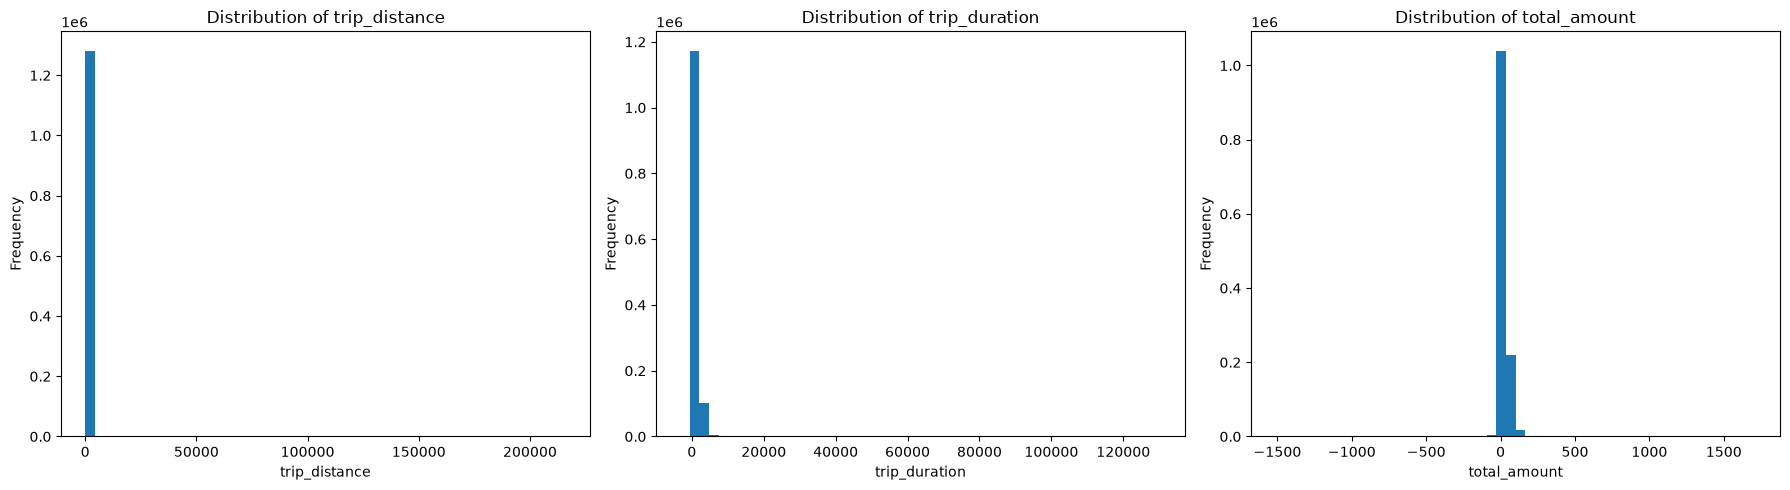

In [35]:
import matplotlib.pyplot as plt

features = [
    "trip_distance",
    "trip_duration",
    "total_amount"
]

# Take a sample only for plotting
pdf = (
    yellow_data.select(features)
      .sample(withReplacement=False, fraction=0.01, seed=42)
      .toPandas()
)

# Create 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, feature in zip(axes, features):
    ax.hist(pdf[feature].dropna(), bins=50)
    
    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Using quantiles to detect anomalous values
We used quantiles to decide the values to remove from our features of interest since deciding an arbitrary cutoff would risk excluding many valid records. The quantile summary below shows that at the 99th percentile, all three features exhibit extreme values which ought to be removed.

In [36]:
features = [
    "trip_distance",
    "trip_duration",
    "total_amount"
]

quantiles = [
    0.01, 0.02, 0.03, 0.04,
    0.95, 0.97, 0.98, 0.99
]

# Calculate quantiles for each feature
results = yellow_data.select(features).approxQuantile(
    features,
    quantiles,
    0.01
)

# Print header
print("\n" + "=" * 75)
print("                    QUANTILE SUMMARY")
print("=" * 75)

header = f"{'Quantile':<12}"
for feature in features:
    header += f"{feature:>20}"

print(header)
print("-" * 75)

# Print each quantile and its corresponding values
for i, q in enumerate(quantiles):
    row = f"{q:<12.3f}"
    
    for j in range(len(features)):
        row += f"{results[j][i]:>20.2f}"
    
    print(row)

print("=" * 75)


                    QUANTILE SUMMARY
Quantile           trip_distance       trip_duration        total_amount
---------------------------------------------------------------------------
0.010                       0.00      -1694897908.00            -2265.45
0.020                       0.01               99.00                2.50
0.030                       0.10              137.00                5.08
0.040                       0.35              175.00                7.75
0.950                      13.10             2556.00               80.74
0.970                      17.25             3027.00               91.45
0.980                      18.14             3365.00               98.15
0.990                  398608.62           892846.00           863380.37


# Takeaways
There are clear outliers within the data and anomalies that are extremely unrealistic such as negative trip durations and fares charged to passengers as well as a trip duration of 892846. We will need to decide an appropriate cutoff for the range of values we are willing to accept from each of the three features. 

<b>Deciding cutoffs</b>

Remarkably, from the percentiles output, we see that there is a steep increase in all three features going from the 98th to the 99th percentile. This is likely to suggest that there are a very rare few extreme outliers likely from some technical issues with the taxi meters that led to these results.

For simplicity's sake, we will remove the values from these columns that are greater than the 98th percentile. We will also remove values that are:

- Below the 3rd percentile `trip_distance`
- Below the 2nd percentile for `trip_duration`
- Below the 2nd percentile for `total_amount`

# Cleaning the dataset
## Objective: Remove all irrelevant rows and columns
We remove select rows where certain column values are deemed infeasible, unrealistic or not representative of the typical circumstances
surrounding yellow taxi trips. We remove certain columns if they are not useful to our analysis. 
Some rows may have unusual values in certain columns due to reasons such as recording mistakes (driver forgetting to reset system), corrupt data or system glitches. 

<b>Rows are to be removed for the following reasons</b>:
- Passenger count is 0 or null
- Trip distance is 0, null or greater than a reasonable threshold. This filters out trips that are unusual in their distance, likely due to errors in the recording system or highly exceptional circumstances.
- Trip durations are unrealistic (e.g a few seconds or too many hours)
- Drop off or pickup area is unknown, outside NYC or an area that motor vehicles cannot travel to

<b> The following columns will be retained with all others removed</b>:
- `PULocationID`: TLC ID for zone where pickup occurred. 
- `total_amount`: Total fare charged to the passengers
- `tpep_pickup_datetime`: Time that taxi picked up passengers

In [37]:
# ------------------------------------------------------------
# 1. Remove invalid passenger counts
# ------------------------------------------------------------

yellow_data = yellow_data.filter(
    (F.col("passenger_count") > 0) &
    F.col("passenger_count").isNotNull()
)


# ------------------------------------------------------------
# 2. Remove invalid trip distances
# ------------------------------------------------------------

yellow_data = yellow_data.filter(
    (F.col("trip_distance") > 0) &
    F.col("trip_distance").isNotNull()
)


# ------------------------------------------------------------
# 3. Remove invalid pickup/dropoff timestamps
# ------------------------------------------------------------

yellow_data = yellow_data.filter(
    F.col("tpep_dropoff_datetime").isNotNull() &
    F.col("tpep_pickup_datetime").isNotNull()
)


# ------------------------------------------------------------
# 4. Remove undesirable trip durations
# ------------------------------------------------------------
print('Shape before filtering: ', yellow_data.count(), ",", len(yellow_data.columns))
yellow_data = yellow_data.filter(
    (F.col("trip_duration") > 60) &
    F.col("trip_duration").isNotNull()
)
print('Shape after filtering: ', yellow_data.count(), ",", len(yellow_data.columns))


# ------------------------------------------------------------
# 5. Calculate percentile cutoffs
# ------------------------------------------------------------

# trip_distance:
#   lower = 3rd percentile
#   upper = 98th percentile
#
# trip_duration and total_amount:
#   lower = 2nd percentile
#   upper = 98th percentile

distance_percentiles = yellow_data.approxQuantile(
    "trip_distance",
    [0.03, 0.98],
    0.01
)

duration_percentiles = yellow_data.approxQuantile(
    "trip_duration",
    [0.02, 0.98],
    0.01
)

amount_percentiles = yellow_data.approxQuantile(
    "total_amount",
    [0.02, 0.98],
    0.01
)


# Extract the cutoff values
distance_lower = distance_percentiles[0]
distance_upper = distance_percentiles[1]

duration_lower = duration_percentiles[0]
duration_upper = duration_percentiles[1]

amount_lower = amount_percentiles[0]
amount_upper = amount_percentiles[1]

print('Shape before filtering: ', yellow_data.count(), ",", len(yellow_data.columns))
yellow_data = yellow_data.filter(
    (F.col("trip_distance") >= distance_lower) &
    (F.col("trip_distance") <= distance_upper) &
    
    (F.col("trip_duration") >= duration_lower) &
    (F.col("trip_duration") <= duration_upper) &
    
    (F.col("total_amount") >= amount_lower) &
    (F.col("total_amount") <= amount_upper)
)

print('Shape after filtering: ', yellow_data.count(), ",", len(yellow_data.columns))
junk_locations = [264, 265, 103, 104, 110]
yellow_data = yellow_data.filter(~F.col("PULocationID").isin(junk_locations))
# get rid of rows where payment_type is null or in the array [5, 6]
yellow_data = yellow_data.filter((F.col("payment_type").isNotNull()) 
                                 & (~F.col("payment_type").isin([5, 6])))
# remove rows where the year in tpep_pickup_datetime is not in range 2023-2026
yellow_data = yellow_data.withColumn(
    "pickup_year", F.year("tpep_pickup_datetime")
)
yellow_data = yellow_data.filter(
    (F.col("pickup_year") >= 2023) & (F.col("pickup_year") <= 2026)
)

# drop unnecessary columns
columns_to_retain_indices = [1, 7, 16]
yellow_data = yellow_data.select([yellow_data.columns[i] for i in columns_to_retain_indices])

# print shape of the cleaned data
print('Shape: ', yellow_data.count(), ",", len(yellow_data.columns))

Shape before filtering:  108504885 , 21


Shape after filtering:  107514130 , 21


Shape before filtering:  107514130 , 21


Shape after filtering:  97020641 , 21


Shape:  96567831 , 3


In [38]:
yellow_data.show(5)

+--------------------+------------+------------+
|tpep_pickup_datetime|PULocationID|total_amount|
+--------------------+------------+------------+
| 2023-01-01 00:32:10|         161|        14.3|
| 2023-01-01 00:55:08|          43|        16.9|
| 2023-01-01 00:25:04|          48|        34.9|
| 2023-01-01 00:10:29|         107|       19.68|
| 2023-01-01 00:50:34|         161|        27.8|
+--------------------+------------+------------+
only showing top 5 rows


### Next step: Add a column for the Borough of each `PULocationID`

In [39]:
import geopandas as gpd
geo_data = gpd.read_file("data/taxi_zones/taxi_zones.shp")

# Create Spark lookup table from geo_data
borough_lookup_pd = (
    geo_data[["LocationID", "borough"]]
    .drop_duplicates()
)

borough_lookup_spark = spark.createDataFrame(borough_lookup_pd)

# Add Borough to yellow_taxi

yellow_data_with_borough = (
    yellow_data
    .join(
        borough_lookup_spark,
        yellow_data["PULocationID"] == borough_lookup_spark["LocationID"],
        how="left"
    )
    .drop("LocationID")
    .withColumnRenamed("borough", "Borough")
)
yellow_data_with_borough = yellow_data_with_borough.withColumnRenamed("tpep_pickup_datetime", "date")

In [40]:
yellow_data_with_borough.show(5)

+-------------------+------------+------------+---------+
|               date|PULocationID|total_amount|  Borough|
+-------------------+------------+------------+---------+
|2023-01-01 00:32:10|         161|        14.3|Manhattan|
|2023-01-01 00:55:08|          43|        16.9|Manhattan|
|2023-01-01 00:25:04|          48|        34.9|Manhattan|
|2023-01-01 00:10:29|         107|       19.68|Manhattan|
|2023-01-01 00:50:34|         161|        27.8|Manhattan|
+-------------------+------------+------------+---------+
only showing top 5 rows


In [41]:
# save the cleaned data to a new parquet file
yellow_data_with_borough.write.parquet("cleaned_data/yellow_data.parquet", mode="overwrite")

# Cleaning the yellow taxi test dataset by applying the same preprocessing steps

In [57]:
# PREPROCESSING TEST DATA (2026 Yellow Taxi Data)
# Apply the same filtering and cleaning steps as training data

input_path_yellow_2026 = "data/year-2026-yellow"
yellow_data_2026 = spark.read.parquet(input_path_yellow_2026)

# Add date column
yellow_data_2026 = yellow_data_2026.withColumn("date", F.to_date("tpep_pickup_datetime"))

# Create trip_duration column
yellow_data_2026 = yellow_data_2026.withColumn("trip_duration", 
   F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime"))

# Remove rows with null trip durations
yellow_data_2026 = yellow_data_2026.filter((F.col("tpep_dropoff_datetime").isNotNull()) 
                                 & (F.col("tpep_pickup_datetime").isNotNull()))

# Remove invalid passenger counts
yellow_data_2026 = yellow_data_2026.filter(
    (F.col("passenger_count") > 0) &
    F.col("passenger_count").isNotNull()
)

# Remove invalid trip distances
yellow_data_2026 = yellow_data_2026.filter(
    (F.col("trip_distance") > 0) &
    F.col("trip_distance").isNotNull()
)

# Remove undesirable trip durations (less than 60 seconds)
yellow_data_2026 = yellow_data_2026.filter(
    (F.col("trip_duration") > 60) &
    F.col("trip_duration").isNotNull()
)

# Apply the same percentile cutoffs from training data
distance_lower = distance_percentiles[0]
distance_upper = distance_percentiles[1]

duration_lower = duration_percentiles[0]
duration_upper = duration_percentiles[1]

amount_lower = amount_percentiles[0]
amount_upper = amount_percentiles[1]

# Filter to percentile ranges
yellow_data_2026 = yellow_data_2026.filter(
    (F.col("trip_distance") >= distance_lower) &
    (F.col("trip_distance") <= distance_upper) &
    
    (F.col("trip_duration") >= duration_lower) &
    (F.col("trip_duration") <= duration_upper) &
    
    (F.col("total_amount") >= amount_lower) &
    (F.col("total_amount") <= amount_upper)
)

# Remove junk locations
junk_locations = [264, 265, 103, 104, 110]
yellow_data_2026 = yellow_data_2026.filter(~F.col("PULocationID").isin(junk_locations))

# Remove invalid payment types
yellow_data_2026 = yellow_data_2026.filter((F.col("payment_type").isNotNull()) 
                                 & (~F.col("payment_type").isin([5, 6])))

# Keep only relevant columns (same as training data)
columns_to_retain_indices = [1, 7, 16]  # PULocationID, total_amount, tpep_pickup_datetime
yellow_data_2026 = yellow_data_2026.select('PULocationID', 'total_amount', 'date')

print('Test data shape: ', yellow_data_2026.count(), ",", len(yellow_data_2026.columns))

# Save preprocessed test data
yellow_data_2026.write.mode("overwrite").parquet("cleaned_data/yellow_taxi_2026_preprocessed")

Test data shape:  12259044 , 3


# Cleaning the FHVHV dataset
## Objective: Remove rows and columns for the same reasons as with the yellow taxi dataset

<b>The columns we will retain are expected to tell the equivalent information (or identical) as the yellow taxi trip data. These are</b>:
- `pickup_datetime`: Time that vehicle picked up passengers.
- `PULocationID`: TLC ID for taxi zone where pickup occurred.

Additionally, we will create a new column called `trip_volume` which will be aggregated to a daily frequency
and will represent the market share of high volume for-hire vehicles.  

In [43]:
pattern = "year-*-fhvhv"  # matches year-2026-yellow, year-2025-yellow, etc.
dirs = sorted([d for d in data_root.glob(pattern) if d.is_dir()])

parquet_files = []
for d in dirs:
    parquet_files.extend(
        sorted([p for p in d.glob("*.parquet") if p.is_file()])
    )

fhvhv_data_raw = None
for p in parquet_files:
    df = spark.read.parquet(str(p))
    if fhvhv_data_raw is None:
        fhvhv_data_raw = df
    else:
        # use unionByName to be robust to column ordering / missing columns
        fhvhv_data_raw = fhvhv_data_raw.unionByName(df, allowMissingColumns=True)

fhvhv_data = fhvhv_data_raw
# fhvhv_data is the big row-wise union of all parquet files
print(f"Combined {len(parquet_files)} files. {fhvhv_data.count()} rows")
fhvhv_data.printSchema()

# print the dataset shape
print('Shape: ', fhvhv_data.count(), ',', len(fhvhv_data.columns))

Combined 41 files. 821546266 rows
root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nul

In [44]:
# data cleaning
# remove rows where trip time is null or less than 10 seconds
fhvhv_data = fhvhv_data.withColumn('trip_time', F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime"))
fhvhv_data = fhvhv_data.filter(fhvhv_data.trip_time.isNotNull() 
                               & (fhvhv_data.trip_time >= 10))
# remove rows where trip miles is null or 0
fhvhv_data = fhvhv_data.filter(fhvhv_data.trip_miles.isNotNull() 
                               & (fhvhv_data.trip_miles > 0))
# remove rows where PULocationID is in the list of invalid IDs
fhvhv_data = fhvhv_data.filter(~F.col("PULocationID").isin(junk_locations))

columns_to_retain_indices = [5, 7]

fhvhv_data = fhvhv_data.select([fhvhv_data.columns[i] for i in columns_to_retain_indices])

fhvhv_data = fhvhv_data.withColumnRenamed("pickup_datetime", "date")
print('Shape: ', fhvhv_data.count(), ',', len(fhvhv_data.columns))

Shape:  821359134 , 2


In [45]:
fhvhv_data.show(5)

+-------------------+------------+
|               date|PULocationID|
+-------------------+------------+
|2023-01-01 00:19:38|          48|
|2023-01-01 00:58:39|         246|
|2023-01-01 00:20:27|           9|
|2023-01-01 00:41:05|         129|
|2023-01-01 00:52:47|         129|
+-------------------+------------+
only showing top 5 rows


In [46]:
# save the cleaned data to a new parquet file
fhvhv_data.write.mode("overwrite").parquet("cleaned_data/fhvhv_data.parquet")

# Cleaning the test FHVHV data

In [47]:
# PREPROCESSING TEST DATA (2026 FHVHV Data)
# Apply the same filtering and cleaning steps as training data

input_path_fhvhv_2026 = "data/year-2026-fhvhv"
fhvhv_data_2026 = spark.read.parquet(input_path_fhvhv_2026)

# Add date column
fhvhv_data_2026 = fhvhv_data_2026.withColumn("date", F.to_date("pickup_datetime"))

# Create trip_time column (in seconds)
fhvhv_data_2026 = fhvhv_data_2026.withColumn('trip_time', 
    F.unix_timestamp("dropoff_datetime") - F.unix_timestamp("pickup_datetime"))

# Remove rows where trip_time is null or less than 10 seconds
fhvhv_data_2026 = fhvhv_data_2026.filter(fhvhv_data_2026.trip_time.isNotNull() 
                               & (F.col("trip_time") >= 10))

# Remove rows with null trip distances
fhvhv_data_2026 = fhvhv_data_2026.filter(F.col("trip_miles").isNotNull() 
                               & (F.col("trip_miles") > 0))

# Calculate percentiles from training FHVHV data for outlier removal
fhvhv_trip_miles_percentiles = fhvhv_data_raw.approxQuantile(
    "trip_miles",
    [0.02, 0.98],
    0.01
)

fhvhv_trip_time_percentiles = fhvhv_data_raw.approxQuantile(
    "trip_time",
    [0.02, 0.98],
    0.01
)

# Extract cutoffs
fhvhv_miles_lower, fhvhv_miles_upper = fhvhv_trip_miles_percentiles
fhvhv_time_lower, fhvhv_time_upper = fhvhv_trip_time_percentiles

# Filter to percentile ranges (same as training)
fhvhv_data_2026 = fhvhv_data_2026.filter(
    (F.col("trip_miles") >= fhvhv_miles_lower) &
    (F.col("trip_miles") <= fhvhv_miles_upper) &
    (F.col("trip_time") >= fhvhv_time_lower) &
    (F.col("trip_time") <= fhvhv_time_upper)
)

# Keep only relevant columns for trip volume calculation
fhvhv_data_2026 = fhvhv_data_2026.select(['pickup_datetime', 'PULocationID', 'date'])

print('Test FHVHV data shape: ', fhvhv_data_2026.count(), ",", len(fhvhv_data_2026.columns))

# Save preprocessed test FHVHV data
fhvhv_data_2026.write.mode("overwrite").parquet("cleaned_data/fhvhv_2026_preprocessed.parquet")

Test FHVHV data shape:  98984876 , 3


In [48]:
residential_data = spark.read.csv('data/MAPPLUTO.csv', header=True, inferSchema=True)
residential_data.show(2)

+--------+-------+-----+---+---+------+------+----------+-------+-------+--------+----------+--------------------+----------+---------+-------------+--------+----------------+---------+---------+---------+---------+--------+--------+-------+-------+-------+---------+---------+---------+-------+---------+---------+--------------------+-------+--------+-------+-------+----------+----------+----------+---------+----------+---------+----------+--------+---------+--------+----------+--------+--------+---------+---------+----+--------+----------+-------+--------+----------+---------+---------+---------+----------+----------+--------+-------------------+--------+--------+-------+--------+--------+----------+-------+---------+------+------+-------+------+-------+------+---------+----------+----------+----------+-------+-----------+------------+---------+----------+-----------+-----+----------+-------+-----------+----------+----------+----------+----------+--------------------+---------+-------

In [49]:
# remove prisons and also vacant areas (code starts with 'V')
residential_data = residential_data.filter(F.col('BldgClass') != 'Y3')
residential_data = residential_data.filter(~F.col('BldgClass').startswith('V'))

In [50]:
# Select only the critical columns for analysis
critical_features = [
    'OBJECTID',          # Unique identifier for each tax lot
    'Borough',            # Which borough
    'UnitsRes',           # Number of residential units (KEY DEMAND PROXY)
    'NumBldgs',           # Number of buildings on tax lot (your insight)
    'BldgClass',          # Building classification (apt, townhouse, etc.)
    'ResArea',            # Residential floor area (density)
    'LotArea',            # Total lot size (spread)
    'NumFloors',          # High-rise vs mid-rise vs low-rise
    'BBL'                 # Borough-Block-Lot identifier
]
 
# Filter to only buildings with residential units
residential_filtered = (residential_data
    .select(critical_features)
    .filter(F.col('UnitsRes') > 0)  # Only buildings with actual residential units
)
print(f"\nTotal residential tax lots: {residential_filtered.count()}")
print(f"Total residential units: {residential_filtered.agg({'UnitsRes': 'sum'}).collect()[0][0]}")



Total residential tax lots: 767063
Total residential units: 3729426


In [51]:
# Filter geopandas geodataframe to match PySpark filtered data

import geopandas as gpd

# Load the full shapefile
residential_geo_raw_data = gpd.read_file('data/MAPPLUTO/MAPPLUTO.shp')

# Get the list of OBJECTIDs from the filtered PySpark dataframe
# First, convert PySpark dataframe to list of OBJECTIDs
objectid_list = residential_filtered.select('OBJECTID').rdd.flatMap(lambda x: x).collect()

print(f"Number of residential buildings with units: {len(objectid_list)}")

# Filter geopandas dataframe to only include OBJECTIDs in the filtered list
features = ['OBJECTID', 'geometry']
residential_geo_data = residential_geo_raw_data[
    residential_geo_raw_data['OBJECTID'].isin(objectid_list)
][features]

print(f"Geodataframe shape: {residential_geo_data.shape}")
print(f"Sample data:")
print(residential_geo_data.head())

# Verify: check that all OBJECTIDs match
print(f"\nVerification - OBJECTIDs in geo_data: {len(residential_geo_data)}")
print(f"OBJECTIDs in filtered data: {len(objectid_list)}")
print(f"Match: {len(residential_geo_data) == len(objectid_list)}")

Number of residential buildings with units: 767063
Geodataframe shape: (767063, 2)
Sample data:
    OBJECTID                                           geometry
5          6  POLYGON ((-8238822.37 4968678.859, -8238850.69...
6          7  POLYGON ((-8238850.691 4968669.142, -8238862.3...
7          8  POLYGON ((-8239065.098 4968596.127, -8239076.9...
9         10  POLYGON ((-8238982.993 4968801.027, -8238982.8...
11        12  POLYGON ((-8239402.588 4969155.989, -8239332.1...

Verification - OBJECTIDs in geo_data: 767063
OBJECTIDs in filtered data: 767063
Match: True


In [52]:
# Spatial join residential buildings to LocationIDs and aggregate by zone

# Step 1: Convert PySpark dataframe to pandas/geopandas for spatial operations
residential_pandas = residential_filtered.toPandas()

# Step 2: Add geometry to residential data by merging with residential_geo_data
residential_with_geo = residential_geo_data.merge(
    residential_pandas,
    on='OBJECTID',
    how='inner'
)

# Convert to GeoDataFrame if not already
residential_with_geo = gpd.GeoDataFrame(residential_with_geo, geometry='geometry')
residential_with_geo.head()

,OBJECTID,geometry,Borough,UnitsRes,NumBldgs,BldgClass,ResArea,LotArea,NumFloors,BBL
0,6,"POLYGON ((-8238822.37 4968678.859, -8238850.69...",MN,42,1.0,RM,32843.0,7780.0,6.0,1000077501
1,7,"POLYGON ((-8238850.691 4968669.142, -8238862.3...",MN,1,1.0,RM,9807.0,3095.0,4.5,1000077502
2,8,"POLYGON ((-8239065.098 4968596.127, -8239076.9...",MN,97,1.0,RM,126420.0,9053.0,19.0,1000087501
3,10,"POLYGON ((-8238982.993 4968801.027, -8238982.8...",MN,3,1.0,RM,5461.0,2242.0,5.0,1000117501
4,12,"POLYGON ((-8239402.588 4969155.989, -8239332.1...",MN,293,1.0,D8,331746.0,13465.0,31.0,1000150022


In [53]:
# Reproject to match if they differ
if residential_with_geo.crs != geo_data.crs:
    print(f"  -> Reprojecting residential_with_geo to match geo_data CRS...")
    residential_with_geo = residential_with_geo.to_crs(geo_data.crs)
    print(f"  -> Done!")
 
# Step 3: Spatial join - assign each building to its LocationID zone
buildings_by_zone = gpd.sjoin(
    residential_with_geo,
    geo_data,
    how='left',
    predicate='within'
)
aggregation_dict = {
    'UnitsRes': 'sum',             # Total residential units
    'NumBldgs': 'sum',             # Total number of buildings
    'ResArea': 'sum',              # Total residential floor area
    'LotArea': 'sum',              # Total lot area
    'NumFloors': 'mean',           # Average number of floors
}
 
demand_proxy_by_zone = buildings_by_zone.groupby('LocationID').agg(aggregation_dict)
 
# Rename columns to be more descriptive
demand_proxy_by_zone = demand_proxy_by_zone.rename(columns={
    'UnitsRes': 'TotalResidentialUnits',
    'NumBldgs': 'TotalNumBldgs',
    'ResArea': 'TotalResidentialArea',
    'LotArea': 'TotalLotArea',
    'YearBuilt': 'AvgYearBuilt',
    'NumFloors': 'AvgNumFloors'
})
 
# Add count of building lots (number of rows per zone)
demand_proxy_by_zone['NumBuildingLots'] = buildings_by_zone.groupby('LocationID').size()

  -> Reprojecting residential_with_geo to match geo_data CRS...
  -> Done!


In [54]:
 
print(f"\n{'='*60}")
print(f"DEMAND PROXY BY LOCATION/ZONE")
print(f"{'='*60}")
print(f"Number of zones: {len(demand_proxy_by_zone)}")
print(f"\nColumns in result:")
print(demand_proxy_by_zone.columns.tolist())
print(f"\nSample data:")
print(demand_proxy_by_zone.head(10))
 
print(f"\nSummary statistics:")
print(demand_proxy_by_zone.describe())



DEMAND PROXY BY LOCATION/ZONE
Number of zones: 239

Columns in result:
['TotalResidentialUnits', 'TotalNumBldgs', 'TotalResidentialArea', 'TotalLotArea', 'AvgNumFloors', 'NumBuildingLots']

Sample data:
            TotalResidentialUnits  TotalNumBldgs  TotalResidentialArea  \
LocationID                                                               
3.0                          9674         6268.0             9671960.0   
4.0                         13758          564.0            11224175.0   
5.0                          9413         8056.0            12647308.0   
6.0                          5482         3915.0             6511248.0   
7.0                         39273         8182.0            31054624.0   
9.0                          7465         7907.0             8887057.0   
10.0                        12338        10525.0            11973552.0   
11.0                        12049         4833.0            10501671.0   
13.0                         8267           35.0        

In [55]:
print("Shape:", demand_proxy_by_zone.shape)
demand_proxy_by_zone.head()

Shape: (239, 6)


,TotalResidentialUnits,TotalNumBldgs,TotalResidentialArea,TotalLotArea,AvgNumFloors,NumBuildingLots
LocationID,,,,,,
3.0,9674,6268.0,9671960.0,16660256.0,1.950959,5191
4.0,13758,564.0,11224175.0,3847828.0,5.615801,465
5.0,9413,8056.0,12647308.0,23359782.0,2.142045,7391
6.0,5482,3915.0,6511248.0,14518605.0,1.969606,3171
7.0,39273,8182.0,31054624.0,20521217.0,2.679809,6713


In [56]:
# save to CSV
demand_proxy_by_zone.to_csv('cleaned_data/residential_data.csv', index=True)